# Titanic: End-to-End Machine Learning Project (Binary Classification)

This notebook follows the **Chapter 2 end-to-end workflow** style from *Hands-On Machine Learning (3rd ed.)*:

1. Look at the big picture  
2. Get the data  
3. Explore and visualize the data  
4. Prepare the data for ML algorithms (pipelines)  
5. Select a model and train it  
6. Fine-tune your model  
7. Present your solution (metrics + conclusions)  
8. (Optional) Notes on launch/monitor/maintain  

**Goal:** Predict `Survived` (0/1) using the other columns.


## 1) Look at the Big Picture

### Frame the problem
- **Supervised learning** (labels exist: `Survived`)
- **Binary classification** (0/1)
- **Batch learning** (static CSV files; we retrain occasionally)

### Select performance measures
We will use multiple metrics because class balance and costs can matter:
- Accuracy
- Precision / Recall
- F1-score
- ROC AUC


## 2) Get the Data

If you downloaded `titanic.tgz`, you can unzip it to get `train.csv` and `test.csv`.
If you already have the CSVs, just set `TRAIN_PATH` and `TEST_PATH` below.

**In this ChatGPT environment**, your files may already be at:
- `/mnt/data/train.csv`
- `/mnt/data/test.csv`


In [1]:
from pathlib import Path

TRAIN_PATH = Path("train.csv")
TEST_PATH  = Path("test.csv")

TRAIN_PATH, TEST_PATH


(WindowsPath('train.csv'), WindowsPath('test.csv'))

In [2]:
import pandas as pd

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
test_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [3]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 3) Explore and Visualize the Data

We’ll do quick EDA similar to Chapter 2:
- Basic stats
- Target distribution
- Missing values
- Simple plots


In [4]:
import numpy as np

# Target distribution
train_df["Survived"].value_counts(), train_df["Survived"].value_counts(normalize=True)


(Survived
 0    549
 1    342
 Name: count, dtype: int64,
 Survived
 0    0.616162
 1    0.383838
 Name: proportion, dtype: float64)

In [5]:
# Missing values (fraction missing per column)
missing = train_df.isna().mean().sort_values(ascending=False)
missing


Cabin          0.771044
Age            0.198653
Embarked       0.002245
PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
dtype: float64

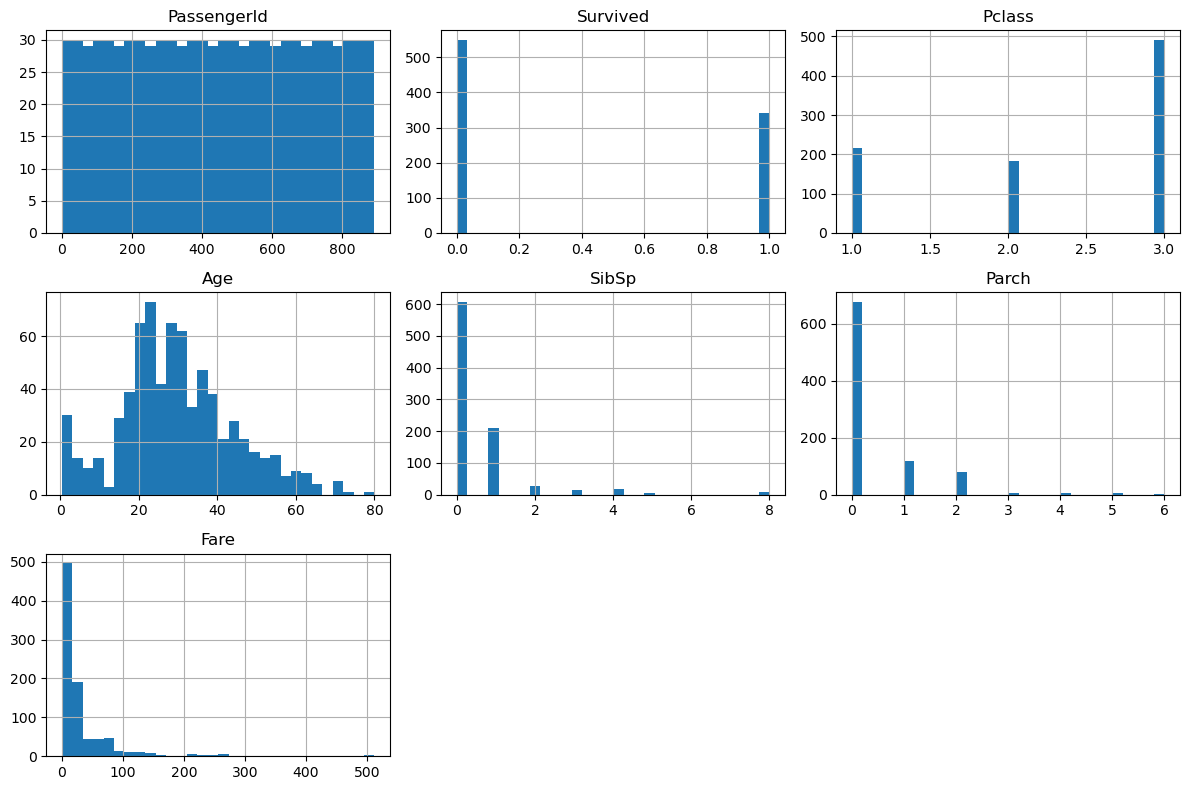

In [6]:
import matplotlib.pyplot as plt

# Histograms for numeric columns (like Chapter 2)
train_df.select_dtypes(include=["number"]).hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()


In [7]:
# Quick look at survival rates by Sex and Pclass (simple sanity check EDA)
group_sex = train_df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
group_pclass = train_df.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)

group_sex, group_pclass


(Sex
 female    0.742038
 male      0.188908
 Name: Survived, dtype: float64,
 Pclass
 1    0.629630
 2    0.472826
 3    0.242363
 Name: Survived, dtype: float64)

## 4) Prepare the Data for Machine Learning Algorithms

We will build a **preprocessing pipeline** that:
- imputes missing numeric values (median)
- scales numeric features (StandardScaler)
- imputes missing categorical values (most frequent)
- one-hot encodes categorical features

This matches the Chapter 2 idea: make transformations **reproducible** with pipelines.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = train_df.drop(columns=["Survived"])
y = train_df["Survived"]

# Hold-out validation split (stratified like best practice)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

numeric_features, categorical_features


(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'],
 ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'])

## 5) Select a Model and Train It (Baselines)

We’ll try multiple models and compare them using consistent evaluation.

Models:
- Logistic Regression (strong baseline)
- SGDClassifier (fast linear model trained with SGD)
- Random Forest (non-linear ensemble)
- Gradient Boosting (strong tabular model)
- SVC (often strong, but can be slower)


In [9]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

def eval_metrics(y_true, y_pred, y_proba=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    out["roc_auc"] = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    return out

models = {
    "LogReg": LogisticRegression(max_iter=2000, random_state=42),
    "SGD(log_loss)": SGDClassifier(loss="log_loss", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=400, random_state=42),
    "GradBoost": GradientBoostingClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42),
}


In [10]:
import pandas as pd

baseline_rows = []
trained_pipes = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", clf)])
    pipe.fit(X_train, y_train)
    trained_pipes[name] = pipe
    
    y_pred = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1] if hasattr(pipe.named_steps["model"], "predict_proba") else None
    
    m = eval_metrics(y_val, y_pred, y_proba)
    m["model"] = name
    baseline_rows.append(m)

baseline_df = pd.DataFrame(baseline_rows).set_index("model").sort_values("f1", ascending=False)
baseline_df


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogReg,0.826816,0.806452,0.724638,0.763359,0.853228
SVC,0.821229,0.793651,0.724638,0.757576,0.850988
SGD(log_loss),0.804469,0.774194,0.695652,0.732824,0.862582
RandomForest,0.815642,0.846154,0.637681,0.727273,0.845125
GradBoost,0.804469,0.826923,0.623188,0.710744,0.826087


In [11]:
# Optional: view confusion matrix for the best baseline model by F1
best_baseline_name = baseline_df.index[0]
best_baseline = trained_pipes[best_baseline_name]

y_pred_best = best_baseline.predict(X_val)
confusion_matrix(y_val, y_pred_best), best_baseline_name


(array([[98, 12],
        [19, 50]], dtype=int64),
 'LogReg')

## 6) Fine-Tune Your Model (GridSearchCV)

We will fine-tune a few promising models using cross-validation:
- Logistic Regression (tune `C`)
- Random Forest (tree depth / splits / number of trees)
- Gradient Boosting (learning rate / n_estimators / depth)

We use **F1** as the scoring metric (balances precision and recall).


In [12]:
from sklearn.model_selection import GridSearchCV

# 6.1 Logistic Regression tuning
logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

logreg_param_grid = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__solver": ["lbfgs"],
}

logreg_grid = GridSearchCV(
    logreg_pipe,
    param_grid=logreg_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
logreg_grid.fit(X_train, y_train)

logreg_grid.best_params_, logreg_grid.best_score_


({'model__C': 10.0, 'model__solver': 'lbfgs'}, 0.7493721839373564)

In [13]:
# 6.2 Random Forest tuning
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [200, 500, 800],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

rf_grid.best_params_, rf_grid.best_score_


({'model__max_depth': None,
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 5,
  'model__n_estimators': 200},
 0.7470709492391666)

In [14]:
# 6.3 Gradient Boosting tuning
gb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [1.0, 0.8],
}

gb_grid = GridSearchCV(
    gb_pipe,
    param_grid=gb_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)

gb_grid.best_params_, gb_grid.best_score_


({'model__learning_rate': 0.05,
  'model__max_depth': 4,
  'model__n_estimators': 100,
  'model__subsample': 0.8},
 0.7614317936648034)

## 7) Present Your Solution (Compare Tuned Models + Explain)

We evaluate the tuned models on the **held-out validation set** and compare.
Then we’ll pick one and train it on the full training data for predictions on `test.csv`.


In [15]:
tuned = {
    "LogReg_tuned": logreg_grid.best_estimator_,
    "RF_tuned": rf_grid.best_estimator_,
    "GB_tuned": gb_grid.best_estimator_,
}

tuned_rows = []
for name, pipe in tuned.items():
    y_pred = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1] if hasattr(pipe.named_steps["model"], "predict_proba") else None
    
    m = eval_metrics(y_val, y_pred, y_proba)
    m["model"] = name
    tuned_rows.append(m)

tuned_df = pd.DataFrame(tuned_rows).set_index("model").sort_values("f1", ascending=False)
tuned_df


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogReg_tuned,0.798883,0.746269,0.724638,0.735294,0.859552
GB_tuned,0.793296,0.785714,0.637681,0.704000,0.829842
RF_tuned,0.798883,0.823529,0.608696,0.700000,0.846377


In [16]:
# Detailed report for best tuned model
best_tuned_name = tuned_df.index[0]
best_tuned = tuned[best_tuned_name]

y_pred = best_tuned.predict(X_val)
print("Best tuned model:", best_tuned_name)
print(classification_report(y_val, y_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_val, y_pred))


Best tuned model: LogReg_tuned
              precision    recall  f1-score   support

           0      0.830     0.845     0.838       110
           1      0.746     0.725     0.735        69

    accuracy                          0.799       179
   macro avg      0.788     0.785     0.787       179
weighted avg      0.798     0.799     0.798       179

Confusion matrix:
 [[93 17]
 [19 50]]


### Interpreting the results (write-up guide)

When you compare models, include a short explanation like:

- **Logistic/SGD** are linear models → good baseline, fast, often need scaling.
- **Random Forest / Gradient Boosting** capture **non-linear** patterns and feature interactions.
- **Precision vs Recall tradeoff**:  
  - higher **precision** means fewer false positives  
  - higher **recall** means fewer false negatives  
- **F1** is useful when you want a balanced score.
- **ROC AUC** measures ranking quality across all thresholds.

Also mention any dataset issues found in EDA (missing values, categorical features, etc.) and how the pipeline handled them.


## 8) (Optional) Launch, Monitor, Maintain (Discussion)

If this were deployed:
- Save the fitted pipeline (e.g., `joblib.dump(best_model, "titanic_model.joblib")`)
- Monitor data drift (feature distributions changing)
- Monitor performance drift (metrics drop over time)
- Retrain periodically if needed


In [17]:
# Train best tuned model on full training set and generate predictions for test.csv
best_name = tuned_df.index[0]
best_model = tuned[best_name]

best_model.fit(X, y)

test_pred = best_model.predict(test_df)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_pred.astype(int)
})

submission.head()


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>]], dtype=object)

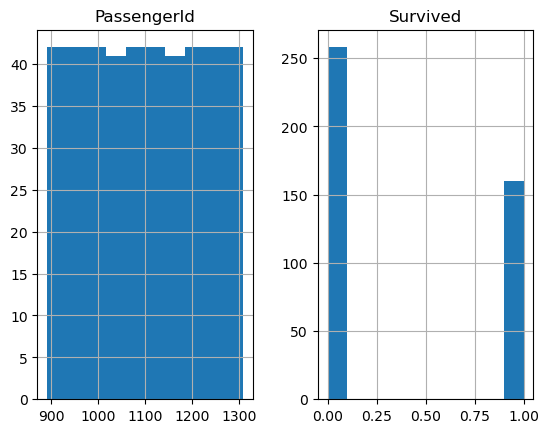

In [23]:
submission.hist()